# 01. EDA (Batch 1 + 2 + 3)
위에서부터 순서대로 실행하세요. **0~3: 준비(불러오기·정리·피처)**, **Q1~Q5: 질문별 EDA** 입니다.

## 0. 준비

In [1]:
import os, re, pickle, logging, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
import mat73
logging.disable(logging.CRITICAL)          # mat73 의 'string type not supported' 경고 숨김 (결과에 영향 없음)
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.family': 'AppleGothic', 'axes.unicode_minus': False,
                     'figure.dpi': 110, 'font.size': 11, 'axes.grid': True, 'grid.alpha': .25})

DATA_DIR = os.path.abspath('../data')
CACHE_DIR = os.path.join(DATA_DIR, 'cache')           # 불러온 결과를 저장해 두는 곳 (두 번째부터는 몇 초)
FILES = {
    'b1': '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'b2': '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    'b3': '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
BC = {'b1': '#1f77b4', 'b2': '#ff7f0e', 'b3': '#2ca02c'}
BN = {'b1': 'Batch 1', 'b2': 'Batch 2', 'b3': 'Batch 3'}
BATCHES = ['b1', 'b2', 'b3']
N_EARLY = 101                                          # 사이클 인덱스 0~100 (ΔQ 에 필요한 범위)
EOL_Q = 0.88                                           # 공칭 1.1 Ah 의 80% = 수명 종료(EOL) 기준
V = np.linspace(3.6, 2.0, 1000)                        # Qdlin 의 전압 축 (3.6V → 2.0V, 1000 포인트)

## 1. 3개 배치 불러오기
원본(.mat)은 수 GB 라서 필요한 것만 뽑아 캐시에 저장합니다: **요약값 전체(summary)** + **초기 100 사이클의 Qdlin**(ΔQ 계산용).
처음 한 번만 오래 걸립니다(배치당 20~30초).

In [2]:
SUMMARY_KEYS = ['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']

def pad(arrs, n=1000):
    """길이가 n 이 아닌 사이클(비어 있는 사이클 0 등)은 NaN 행으로 채움"""
    out = np.full((len(arrs), n), np.nan)
    for j, a in enumerate(arrs):
        a = np.asarray(a, dtype=float).ravel()
        if a.size == n: out[j] = a
    return out

def load_batch(tag):
    path = os.path.join(CACHE_DIR, f'{tag}.pkl')
    if os.path.exists(path):
        return pickle.load(open(path, 'rb'))
    b = mat73.loadmat(os.path.join(DATA_DIR, FILES[tag]))['batch']
    cells = []
    for i in range(len(b['cycle_life'])):
        cyc = b['cycles'][i]
        cells.append(dict(
            cid=f'{tag}c{i}', batch=tag,
            policy=str(b['policy_readable'][i]),
            cycle_life=float(np.asarray(b['cycle_life'][i]).ravel()[0]),
            summary={k: np.asarray(b['summary'][i][k], dtype=float).ravel() for k in SUMMARY_KEYS},
            Qdlin=pad(cyc['Qdlin'][:N_EARLY]),
        ))
    os.makedirs(CACHE_DIR, exist_ok=True)
    pickle.dump(cells, open(path, 'wb'))
    return cells

cells = []
for t in BATCHES:
    c = load_batch(t); cells += c
    print(f'{BN[t]} : {len(c)}셀 로드')
print('전체', len(cells), '셀')

Batch 1 : 46셀 로드
Batch 2 : 47셀 로드
Batch 3 : 46셀 로드
전체 139 셀


## 2. 분석 대상 정리
- 원본에는 논문 본 실험이 아닌 셀(`VarCharge`, `SLOWCYCLE`)이 섞여 있어 **제외**합니다.
- `cycle_life` 가 비어 있는 셀은 EOL(0.88 Ah)에 **아직 도달하지 못한 셀**입니다. 값을 임의로 채우지 않고 `censored` 로 표시해 수명이 필요한 분석에서는 뺍니다.

In [3]:
rows = []
for c in cells:
    p = c['policy']
    if p.startswith('VarCharge') or 'SLOWCYCLE' in p:
        continue
    q = c['summary']['QDischarge']; q = q[np.isfinite(q)]
    rows.append(dict(cid=c['cid'], batch=c['batch'], policy=p.replace('-newstructure', ''),
                     newstructure='newstructure' in p, cycle_life=c['cycle_life'],
                     n_cycles=len(c['summary']['cycle']), end_QD=np.median(q[-10:])))
df = pd.DataFrame(rows)
df['censored'] = df.cycle_life.isna()
df['log_life'] = np.log10(df.cycle_life)
keep = [c for c in cells if c['cid'] in set(df.cid)]            # df 와 같은 순서 유지
assert [c['cid'] for c in keep] == df.cid.tolist()

print('제외한 셀 :', [c['cid'] for c in cells if c['cid'] not in set(df.cid)])
print()
print(df.groupby('batch').agg(셀수=('cid', 'count'), censored=('censored', 'sum')))
print()
print('수명 미도달(censored) 셀 :'); print(df[df.censored][['cid', 'policy', 'n_cycles', 'end_QD']].to_string(index=False))

제외한 셀 : ['b2c22', 'b2c23', 'b2c35', 'b2c36', 'b2c37', 'b2c38', 'b2c39', 'b2c40']

       셀수  censored
batch              
b1     46         0
b2     39         0
b3     46         2

수명 미도달(censored) 셀 :
  cid         policy  n_cycles   end_QD
b3c23 4.8C(80%)-4.8C      2189 0.938040
b3c32 4.8C(80%)-4.8C      2237 0.974498


## 3. 피처 준비 (Q1~Q5 에서 공통 사용)
초기 100 사이클(2~100)을 요약한 **후보 피처**를 한 표(`D`)로 만듭니다.
- **ΔQ(V) 피처**: ΔQ(V) = Qdlin[사이클 100] − Qdlin[사이클 10] 를 숫자로 요약 (변화량이 작아 log10 사용)
- **요약값 피처**: 사이클 2~100 의 **중앙값**(일부 사이클의 측정 스파이크가 평균을 오염시키기 때문)
- **충전 프로토콜 피처**: `C1(Q1%)-C2` → C1, 전환점, C2, 0→80% 평균 C-rate(`avgC`)

In [4]:
# --- ΔQ(V) 와 통계 피처
DQ = np.vstack([c['Qdlin'][100] - c['Qdlin'][10] for c in keep])            # (셀 수, 1000)
dq_ok = np.isfinite(DQ).all(axis=1)

def dq_feats(dq):
    return {'dq_logvar':  np.log10(np.var(dq)),            # 분산
            'dq_logmean': np.log10(abs(np.mean(dq))),      # 평균
            'dq_logmin':  np.log10(abs(np.min(dq))),       # 최솟값(가장 깊이 파인 곳)
            'dq_skew':    stats.skew(dq), 'dq_kurt': stats.kurtosis(dq)}

# --- 초기 요약값
def clean_qd(qd, lo=0.7, hi=1.3, k=5):
    """방전 용량 스파이크 제거: 범위 밖 값은 NaN → 이동 중앙값"""
    qd = np.asarray(qd, dtype=float).copy(); qd[(qd < lo) | (qd > hi)] = np.nan
    return pd.Series(qd).rolling(k, center=True, min_periods=1).median().to_numpy()

def early_feats(c, n=100):
    s = c['summary']; m = (s['cycle'] >= 2) & (s['cycle'] <= n)
    qd = clean_qd(s['QDischarge'])[m]; x = s['cycle'][m]; good = np.isfinite(qd)
    ir = s['IR'][m]; ir = ir[ir > 0]                                    # IR=0 은 측정 누락 → 제외
    return {'QD_mean': np.nanmedian(qd), 'QD_slope': np.polyfit(x[good], qd[good], 1)[0],
            'IR': np.median(ir) if ir.size else np.nan,
            'Tavg': np.nanmedian(s['Tavg'][m]), 'Tmax': np.nanmedian(s['Tmax'][m]),
            'chargetime': np.nanmedian(s['chargetime'][m])}

# --- 충전 프로토콜
def protocol_feats(policy):
    m = re.match(r'^([\d.]+)C\((\d+)%\)-([\d.]+)C', policy)
    c1, sw, c2 = float(m.group(1)), float(m.group(2)), float(m.group(3))
    t = sw / 100 / c1 + (80 - sw) / 100 / c2                            # 0→80% 충전 시간(h)
    return {'C1': c1, 'switch': sw, 'C2': c2, 'avgC': 0.8 / t}

feat_dq = pd.DataFrame([dq_feats(DQ[i]) if dq_ok[i] else {} for i in range(len(df))])
feat_early = pd.DataFrame([early_feats(c) for c in keep])
feat_proto = pd.DataFrame([protocol_feats(p) for p in df.policy])
D = pd.concat([df, feat_dq, feat_early, feat_proto], axis=1)
L = D[~D.censored]                                                       # 수명이 있는 셀만
print('피처 표 :', D.shape, '| 수명이 있는 셀', len(L))
print('결측 :', D.drop(columns=['cycle_life', 'log_life']).isna().sum()[lambda x: x > 0].to_dict(),
      '(IR: Batch 2 마지막 6셀은 초기 IR 이 전부 0 → 결측 처리)')
D.head()

피처 표 : (131, 24) | 수명이 있는 셀 129
결측 : {'IR': 6} (IR: Batch 2 마지막 6셀은 초기 IR 이 전부 0 → 결측 처리)


,cid,batch,policy,newstructure,cycle_life,n_cycles,end_QD,censored,log_life,dq_logvar,...,QD_mean,QD_slope,IR,Tavg,Tmax,chargetime,C1,switch,C2,avgC
0,b1c0,b1,3.6C(80%)-3.6C,False,1190.0,1189,1.026688,False,3.075547,-5.051527,...,1.076534,0.000016,0.016619,31.566972,35.353580,13.358212,3.6,80.0,3.6,3.6
1,b1c1,b1,3.6C(80%)-3.6C,False,1179.0,1178,1.038721,False,3.071514,-5.135776,...,1.081621,0.000006,0.016923,31.258835,34.137924,13.341623,3.6,80.0,3.6,3.6
2,b1c2,b1,3.6C(80%)-3.6C,False,1177.0,1176,1.043592,False,3.070776,-4.951883,...,1.085670,0.000010,0.016769,31.406702,34.527420,13.341570,3.6,80.0,3.6,3.6
3,b1c3,b1,4C(80%)-4C,False,1226.0,1225,0.972497,False,3.088490,-4.386348,...,1.085377,0.000014,0.016315,29.847548,30.585636,12.092243,4.0,80.0,4.0,4.0
4,b1c4,b1,4C(80%)-4C,False,1227.0,1226,1.021984,False,3.088845,-4.604779,...,1.083257,0.000017,0.016677,31.367527,34.341938,12.092205,4.0,80.0,4.0,4.0


## 4. Q1. Cycle Life 분포는 어떻게 생겼는가?
**① 히스토그램과 배치별 분포**

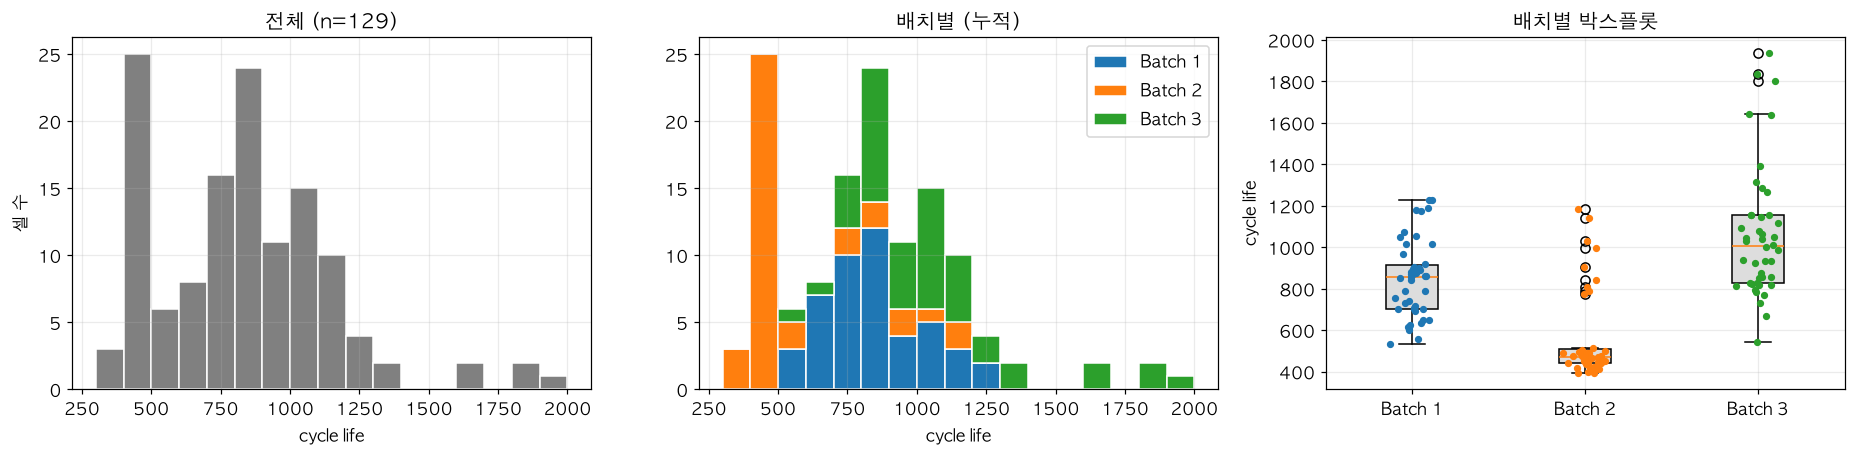

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.3))
bins = np.arange(300, 2100, 100)
axes[0].hist(L.cycle_life, bins=bins, color='gray', edgecolor='w')
axes[0].set(title=f'전체 (n={len(L)})', xlabel='cycle life', ylabel='셀 수')
axes[1].hist([L[L.batch == t].cycle_life for t in BATCHES], bins=bins, stacked=True,
             color=[BC[t] for t in BATCHES], edgecolor='w', label=[BN[t] for t in BATCHES])
axes[1].set(title='배치별 (누적)', xlabel='cycle life'); axes[1].legend()
axes[2].boxplot([L[L.batch == t].cycle_life for t in BATCHES], tick_labels=[BN[t] for t in BATCHES], patch_artist=True, boxprops=dict(facecolor='#ddd'))
for i, t in enumerate(BATCHES):
    y = L[L.batch == t].cycle_life; axes[2].scatter(np.random.RandomState(0).normal(i + 1, .05, len(y)), y, s=14, color=BC[t], zorder=3)
for r in D[D.censored].itertuples():
    axes[2].annotate(f'{r.cid}: >{r.n_cycles} (미도달)', (3.4, r.n_cycles), fontsize=8, color='crimson', ha='right')
axes[2].set(title='배치별 박스플롯', ylabel='cycle life'); plt.tight_layout(); plt.show()

**② 장수명(>1,000) / 단수명(<500) 비율**

In [6]:
def summ(g): return pd.Series({'셀수': len(g), '최소': g.min(), '중앙값': g.median(), '최대': g.max(),
                              '장수명(>1000) %': round((g > 1000).mean() * 100, 1), '단수명(<500) %': round((g < 500).mean() * 100, 1)})
tab = L.groupby('batch').cycle_life.apply(summ).unstack(); tab.loc['전체'] = summ(L.cycle_life)
tab.index = [BN.get(i, i) for i in tab.index]
print('수명 미도달(censored) 2셀은 제외한 값 / 미도달 셀은 2,189·2,237 사이클 이상')
tab.round(1)

수명 미도달(censored) 2셀은 제외한 값 / 미도달 셀은 2,189·2,237 사이클 이상


,셀수,최소,중앙값,최대,장수명(>1000) %,단수명(<500) %
Batch 1,46.0,534.0,858.5,1227.0,21.7,0.0
Batch 2,39.0,392.0,472.0,1186.0,7.7,71.8
Batch 3,44.0,541.0,1005.5,1935.0,52.3,0.0
전체,129.0,392.0,828.0,1935.0,27.9,21.7


**③ 이상치 셀 식별 — 왜 유독 짧은가?** 배치 안에서 IQR 기준으로 벗어난 셀, 그리고 가장 짧은/긴 셀을 봅니다.

In [7]:
out = []
for t in BATCHES:
    g = L[L.batch == t]; q1, q3 = g.cycle_life.quantile([.25, .75]); iqr = q3 - q1
    for r in g[(g.cycle_life < q1 - 1.5 * iqr) | (g.cycle_life > q3 + 1.5 * iqr)].itertuples():
        out.append((BN[t], r.cid, r.policy, '신규구조' if r.newstructure else '기존구조', int(r.cycle_life), '높음' if r.cycle_life > q3 else '낮음'))
print('[배치 내 IQR 이상치]'); print(pd.DataFrame(out, columns=['배치', '셀', '프로토콜', '셀 구조', '수명', '방향']).to_string(index=False))

show = ['cid', 'policy', 'newstructure', 'cycle_life', 'dq_logvar', 'avgC', 'Tavg', 'IR']
print('\n[가장 짧은 6셀]'); print(L.nsmallest(6, 'cycle_life')[show].round(3).to_string(index=False))
print('\n[가장 긴 4셀]');   print(L.nlargest(4, 'cycle_life')[show].round(3).to_string(index=False))

low = L.cycle_life.quantile(.10); s_ = L[L.cycle_life <= low]
print(f'\n하위 10% (≤{low:.0f}사이클, {len(s_)}셀) 구성 :', s_.batch.value_counts().to_dict(), '/ 신규구조 비율', round(s_.newstructure.mean(), 2))
cols = ['dq_logvar', 'avgC', 'Tavg', 'IR', 'QD_mean']
print(pd.DataFrame({'하위10% 평균': s_[cols].mean(), '나머지 평균': L[L.cycle_life > low][cols].mean()}).round(3))
b2 = L[L.batch == 'b2']
print('\nBatch 2 안에서 : 기존구조 중앙값', b2[~b2.newstructure].cycle_life.median(), '/ 신규구조 중앙값', b2[b2.newstructure].cycle_life.median())

[배치 내 IQR 이상치]
     배치     셀           프로토콜 셀 구조   수명 방향
Batch 2  b2c7 4.8C(80%)-4.8C 신규구조  777 높음
Batch 2  b2c8   5.2C(58%)-4C 신규구조  904 높음
Batch 2  b2c9 5.6C(26%)-4.5C 신규구조  791 높음
Batch 2 b2c32 4.8C(80%)-4.8C 신규구조  809 높음
Batch 2 b2c33   5.2C(58%)-4C 신규구조 1140 높음
Batch 2 b2c34 5.6C(26%)-4.5C 신규구조 1186 높음
Batch 2 b2c43 4.8C(80%)-4.8C 신규구조 1029 높음
Batch 2 b2c44   5.2C(58%)-4C 신규구조  841 높음
Batch 2 b2c45 5.6C(26%)-4.5C 신규구조  997 높음
Batch 3  b3c7 4.8C(80%)-4.8C 신규구조 1836 높음
Batch 3 b3c38     5C(67%)-4C 신규구조 1935 높음
Batch 3 b3c45 4.8C(80%)-4.8C 신규구조 1801 높음

[가장 짧은 6셀]
  cid         policy  newstructure  cycle_life  dq_logvar  avgC   Tavg    IR
b2c19     6C(60%)-3C         False       392.0     -3.292 4.800 32.789 0.017
 b2c6    3.6C(9%)-5C         False       393.0     -3.682 4.790 33.791 0.016
b2c15    3.6C(9%)-5C         False       396.0     -3.417 4.790 32.856 0.016
b2c21     6C(60%)-3C         False       408.0     -3.332 4.800 33.624 0.017
b2c30 5.6C(26%)-4.5C         False       4

**④ 타깃 변환의 효과** — 수명 분포가 한쪽으로 치우쳐 있어 log 변환 전/후 왜도(skewness)를 비교합니다. (0에 가까울수록 대칭)

전체  : 원래 왜도 +0.89  →  log10 후 -0.09
Batch 1 : 원래 왜도 +0.44  →  log10 후 +0.04
Batch 2 : 원래 왜도 +1.57  →  log10 후 +1.30
Batch 3 : 원래 왜도 +1.21  →  log10 후 +0.50


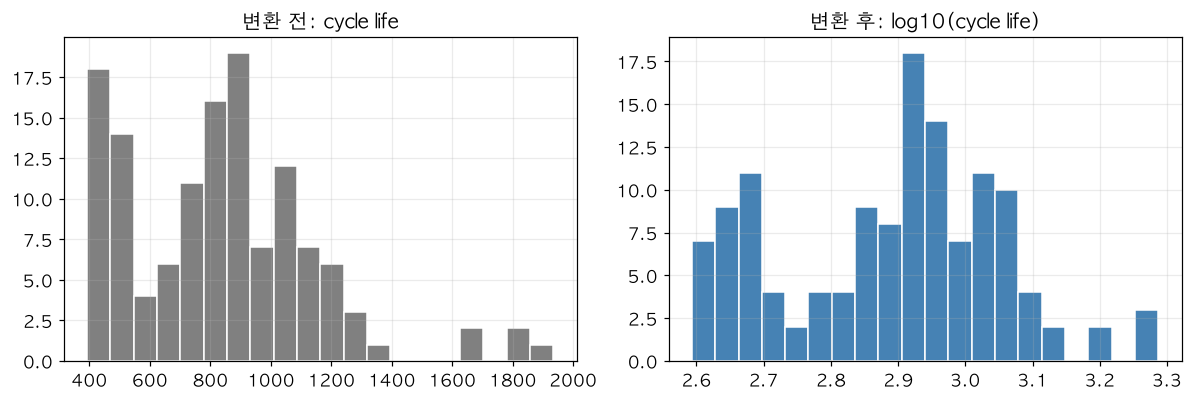

In [8]:
print(f'전체  : 원래 왜도 {stats.skew(L.cycle_life):+.2f}  →  log10 후 {stats.skew(L.log_life):+.2f}')
for t in BATCHES:
    g = L[L.batch == t]; print(f'{BN[t]} : 원래 왜도 {stats.skew(g.cycle_life):+.2f}  →  log10 후 {stats.skew(g.log_life):+.2f}')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(L.cycle_life, bins=20, color='gray', edgecolor='w'); axes[0].set_title('변환 전: cycle life')
axes[1].hist(L.log_life, bins=20, color='steelblue', edgecolor='w'); axes[1].set_title('변환 후: log10(cycle life)'); plt.tight_layout(); plt.show()

## 5. Q2. 열화 곡선 — 방전 용량은 어떻게 감소하는가?
**① 사이클별 방전 용량(Qd) 추이** — 색은 수명(파랑 = 장수명, 빨강 = 단수명), 점선은 수명 미도달 셀. 용량 스파이크는 `clean_qd` 로 제거했습니다.

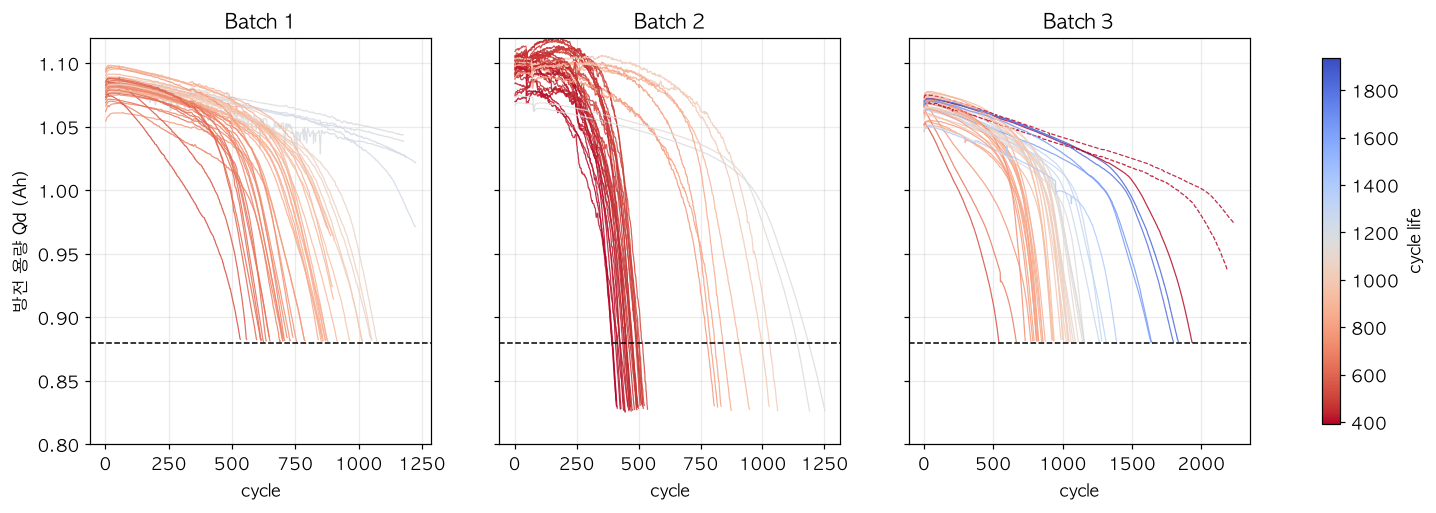

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
cmap = plt.cm.coolwarm_r; lo, hi = L.cycle_life.min(), L.cycle_life.max()
for ax, t in zip(axes, BATCHES):
    for i in D[D.batch == t].index:
        c = keep[i]; s = c['summary']; life = D.cycle_life[i] if not D.censored[i] else D.n_cycles[i]
        ax.plot(s['cycle'], clean_qd(s['QDischarge']), lw=.8, alpha=.85, color=cmap(min(1, (life - lo) / (hi - lo))), ls='--' if D.censored[i] else '-')
    ax.axhline(EOL_Q, color='k', ls='--', lw=1); ax.set(title=BN[t], xlabel='cycle', ylim=(.8, 1.12))
axes[0].set_ylabel('방전 용량 Qd (Ah)')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(lo, hi)); fig.colorbar(sm, ax=axes, label='cycle life', shrink=.9); plt.show()

**② 열화 속도는 일정한가, 가속되는가?** — 수명을 100%로 보고 구간별 용량 기울기(mAh/cycle, 음수 = 열화)를 비교합니다.

In [10]:
def phase_slopes(c, life):
    s = c['summary']; q = clean_qd(s['QDischarge']); x = s['cycle'].astype(float)
    m = (x >= 5) & (x <= life) & np.isfinite(q); x, q = x[m], q[m]
    def sl(a, b):
        w = (x >= a * life) & (x <= b * life); return np.polyfit(x[w], q[w], 1)[0] * 1000
    return {'0~20%': sl(0, .2), '40~60%': sl(.4, .6), '80~100%': sl(.8, 1.0)}

ph = pd.DataFrame([phase_slopes(keep[i], D.cycle_life[i]) for i in L.index], index=L.index)
ph['batch'] = L.batch
print('수명 대비 구간별 평균 기울기 (mAh/cycle)')
print(ph.groupby('batch').mean().rename(index=BN).round(3))

수명 대비 구간별 평균 기울기 (mAh/cycle)
         0~20%  40~60%  80~100%
batch                          
Batch 1 -0.029  -0.090   -0.745
Batch 2  0.011  -0.188   -1.478
Batch 3 -0.037  -0.075   -0.625


**③ Knee point (급격한 열화가 시작되는 지점)** — 용량 곡선을 "완만한 구간 + 가파른 구간" 두 직선으로 이어 붙여 꺾이는 지점을 찾습니다.

         knee사이클_중앙값  knee_하위25  knee_상위25  수명대비_비율  수명_중앙값
batch                                                      
Batch 1       601.39     501.16     683.51     0.75   858.5
Batch 2       343.60     316.22     386.56     0.75   472.0
Batch 3       814.86     671.33     913.83     0.79  1005.5


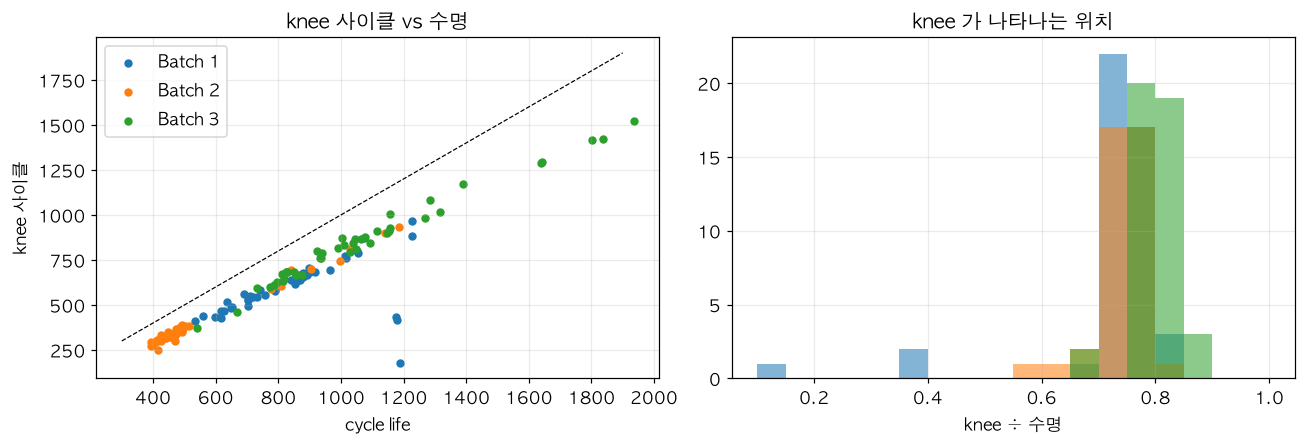


초기(사이클 2~100) 용량 기울기 vs 수명 Spearman ρ = -0.15 (p=0.08) → 초기 용량 추이만으로는 수명을 가르기 어렵다


In [11]:
def find_knee(c, life):
    s = c['summary']; q = clean_qd(s['QDischarge']); x = s['cycle'].astype(float)
    m = (x >= 5) & (x <= life) & np.isfinite(q); x, q = x[m], q[m]
    best = (np.inf, None)
    for k in np.linspace(.15 * life, .95 * life, 60):                    # 꺾이는 위치 후보
        A = np.c_[np.ones_like(x), x, np.maximum(0, x - k)]
        coef = np.linalg.lstsq(A, q, rcond=None)[0]; sse = ((A @ coef - q) ** 2).sum()
        if sse < best[0]: best = (sse, k)
    return best[1]

L2 = L.copy(); L2['knee'] = [find_knee(keep[i], D.cycle_life[i]) for i in L.index]; L2['knee_비율'] = L2.knee / L2.cycle_life
kt = L2.groupby('batch').agg(knee사이클_중앙값=('knee', 'median'), knee_하위25=('knee', lambda x: x.quantile(.25)), knee_상위25=('knee', lambda x: x.quantile(.75)),
                             수명대비_비율=('knee_비율', 'median'), 수명_중앙값=('cycle_life', 'median')).rename(index=BN)
print(kt.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for t in BATCHES:
    g = L2[L2.batch == t]; axes[0].scatter(g.cycle_life, g.knee, s=20, color=BC[t], label=BN[t])
    axes[1].hist(g.knee_비율, bins=np.linspace(.1, 1, 19), alpha=.55, color=BC[t], label=BN[t])
axes[0].plot([300, 1900], [300, 1900], 'k--', lw=.8); axes[0].set(xlabel='cycle life', ylabel='knee 사이클', title='knee 사이클 vs 수명'); axes[0].legend()
axes[1].set(xlabel='knee ÷ 수명', title='knee 가 나타나는 위치'); plt.tight_layout(); plt.show()

e = L.assign(초기기울기=L.QD_slope * 1000)
r, p = stats.spearmanr(e.초기기울기, e.cycle_life)
print(f'\n초기(사이클 2~100) 용량 기울기 vs 수명 Spearman ρ = {r:+.2f} (p={p:.1g}) → 초기 용량 추이만으로는 수명을 가르기 어렵다')

## 6. Q3. ΔQ(V) 곡선 — 초기 사이클에서 차이가 보이는가?
**① ΔQ(V) = Qdlin[사이클 100] − Qdlin[사이클 10]** (전압 3.6 → 2.0 V). 단수명(하위 25%)과 장수명(상위 25%) 셀을 배치별로 비교합니다.

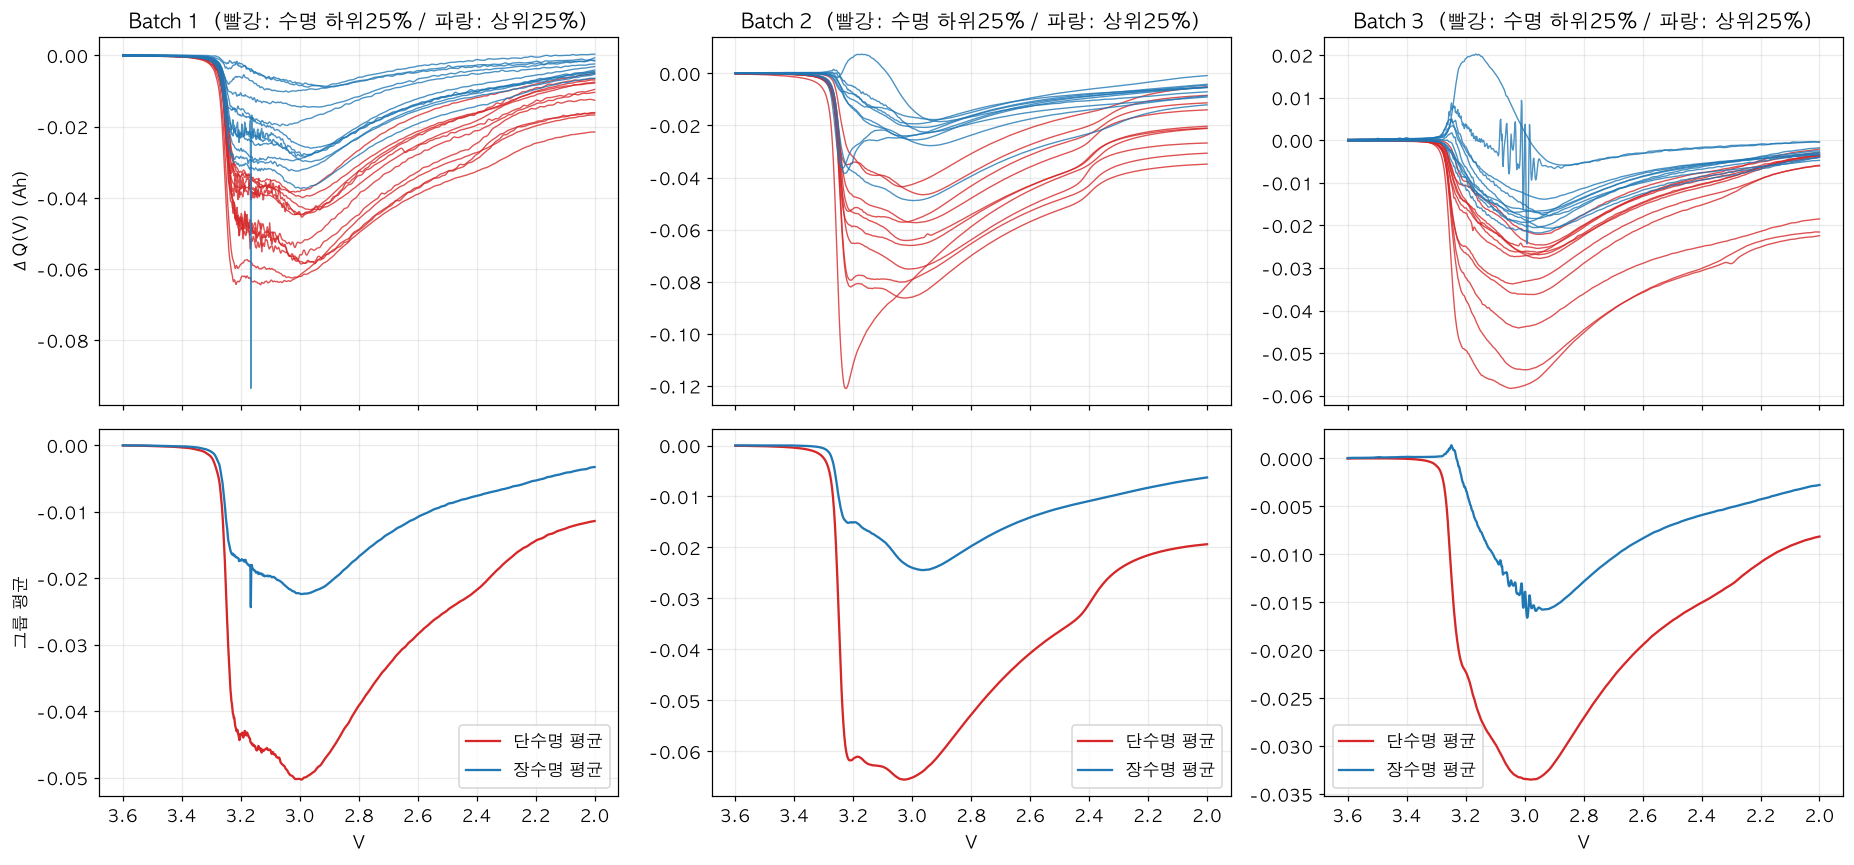

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8), sharex=True)
for j, t in enumerate(BATCHES):
    g = L[(L.batch == t) & dq_ok[L.index]]
    q25, q75 = g.cycle_life.quantile([.25, .75])
    short, long_ = g[g.cycle_life <= q25].index, g[g.cycle_life >= q75].index
    for i in short: axes[0, j].plot(V, DQ[i], color='#d62728', lw=.9, alpha=.8)
    for i in long_: axes[0, j].plot(V, DQ[i], color='#1f77b4', lw=.9, alpha=.8)
    axes[0, j].set_title(f'{BN[t]}  (빨강: 수명 하위25% / 파랑: 상위25%)'); axes[0, j].invert_xaxis()
    axes[1, j].plot(V, DQ[short].mean(0), color='#d62728', label='단수명 평균')
    axes[1, j].plot(V, DQ[long_].mean(0), color='#1f77b4', label='장수명 평균')
    axes[1, j].set_xlabel('V'); axes[1, j].legend()
axes[0, 0].set_ylabel('ΔQ(V) (Ah)'); axes[1, 0].set_ylabel('그룹 평균')
plt.tight_layout(); plt.show()

**② ΔQ 곡선을 구분하는 통계값(피처)** — 수명(log10)과의 Spearman 상관계수. 배치마다 부호가 같은지가 중요합니다.

Spearman 상관계수: ΔQ 피처 vs log10(cycle life)
            Batch 1  Batch 2  Batch 3    통합
dq_logvar     -0.85    -0.72    -0.80 -0.89
dq_logmean    -0.83    -0.72    -0.76 -0.87
dq_logmin     -0.77    -0.70    -0.78 -0.86
dq_skew       -0.57    -0.15    -0.17 -0.41
dq_kurt        0.31     0.49     0.29  0.42


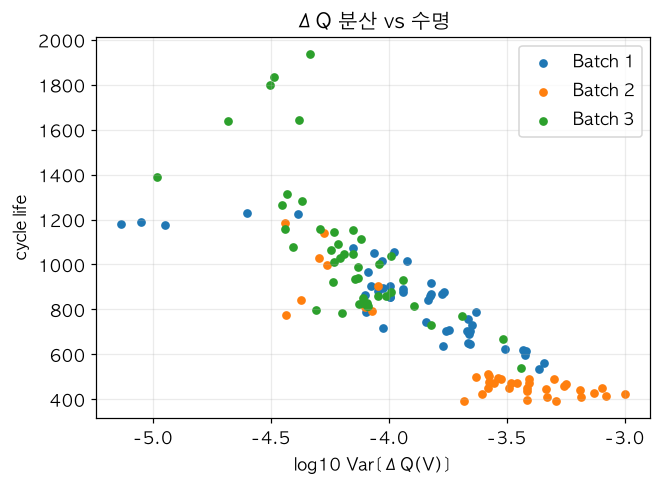

In [13]:
cols = ['dq_logvar', 'dq_logmean', 'dq_logmin', 'dq_skew', 'dq_kurt']
Lk = L[L.dq_logvar.notna()]
rho = {BN[t]: [stats.spearmanr(Lk[Lk.batch == t][c], Lk[Lk.batch == t].log_life)[0] for c in cols] for t in BATCHES}
rho['통합'] = [stats.spearmanr(Lk[c], Lk.log_life)[0] for c in cols]
print('Spearman 상관계수: ΔQ 피처 vs log10(cycle life)'); print(pd.DataFrame(rho, index=cols).round(2))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for t in BATCHES:
    g = Lk[Lk.batch == t]; ax.scatter(g.dq_logvar, g.cycle_life, s=22, color=BC[t], label=BN[t])
ax.set(xlabel='log10 Var[ΔQ(V)]', ylabel='cycle life', title='ΔQ 분산 vs 수명'); ax.legend(); plt.show()

## 7. 모델 설계 근거 — 간이 점검 (3. 모델 설계 전략에서 사용)
본격적인 모델링 전에, **단일 피처(`dq_logvar`) 선형 회귀**를 기준선으로 두고 *어떤 배치로 학습하고 평가하느냐*에 따라 오차가 어떻게 달라지는지 확인합니다. (모델링의 분할 방식을 정하기 위한 점검)

**① 학습/평가 배치 조합별 오차** — MAPE(%)는 원래 수명 단위의 상대오차, 편향은 (예측−실제)/실제의 평균 (양수 = 과대예측)

In [14]:
def mape(y, p): return np.mean(np.abs(y - p) / y) * 100

Lk = L[L.dq_logvar.notna()].copy()
def check(train_b, test_b, feats=['dq_logvar']):
    tr = Lk[Lk.batch.isin(train_b)]; te = Lk[Lk.batch == test_b]
    m = LinearRegression().fit(tr[feats], tr.log_life); p = 10 ** m.predict(te[feats])
    return {'학습 배치': '+'.join(BN[b] for b in train_b), '평가 배치': BN[test_b], '학습 셀 수': len(tr), '평가 셀 수': len(te),
            'MAPE(%)': round(mape(te.cycle_life, p), 1), '편향(%)': round(np.mean((p - te.cycle_life) / te.cycle_life) * 100)}

cases = [(['b1'], 'b2'), (['b1'], 'b3'), (['b1', 'b3'], 'b2'), (['b1', 'b2'], 'b3'), (['b2', 'b3'], 'b1')]
res = pd.DataFrame([check(a, b) for a, b in cases]); res

,학습 배치,평가 배치,학습 셀 수,평가 셀 수,MAPE(%),편향(%)
0,Batch 1,Batch 2,46,39,36.5,35
1,Batch 1,Batch 3,46,44,13.5,-7
2,Batch 1+Batch 3,Batch 2,90,39,32.7,32
3,Batch 1+Batch 2,Batch 3,85,44,14.3,-11
4,Batch 2+Batch 3,Batch 1,83,46,17.7,-5


**② 왜 Batch 2가 어려운가** — 학습 데이터의 수명 범위 밖에 있는 셀의 비율

In [15]:
b1_min, b1_max = Lk[Lk.batch == 'b1'].cycle_life.agg(['min', 'max'])
b12_max = Lk[Lk.batch.isin(['b1', 'b2'])].cycle_life.max()
b2 = Lk[Lk.batch == 'b2']; b3 = Lk[Lk.batch == 'b3']
print(f'Batch 1 수명 범위 : {b1_min:.0f} ~ {b1_max:.0f}')
print(f'Batch 2 셀 중 Batch 1 학습 범위(<{b1_min:.0f}) 밖 : {(b2.cycle_life < b1_min).sum()} / {len(b2)} 셀 ({(b2.cycle_life < b1_min).mean() * 100:.0f}%)')
print(f'Batch 3 셀 중 Batch 1+2 학습 최대({b12_max:.0f}) 초과 : {(b3.cycle_life > b12_max).sum()} / {len(b3)} 셀 ({(b3.cycle_life > b12_max).mean() * 100:.0f}%)')

Batch 1 수명 범위 : 534 ~ 1227
Batch 2 셀 중 Batch 1 학습 범위(<534) 밖 : 30 / 39 셀 (77%)
Batch 3 셀 중 Batch 1+2 학습 최대(1227) 초과 : 9 / 44 셀 (20%)


**③ 분류로 풀면 어떻게 되는가** — 임계값 기준 장수명 비율과 음성(단수명) 셀의 분포

In [16]:
rows = []
for thr in (550, 800):
    y = Lk.cycle_life >= thr
    row = {'임계값': thr, '전체 음성(단수명) 수': int((~y).sum())}
    for t in ['b1', 'b2', 'b3']:
        g = Lk[Lk.batch == t]; row[f'{BN[t]} 장수명 %'] = round((g.cycle_life >= thr).mean() * 100); row[f'{BN[t]} 음성 수'] = int((g.cycle_life < thr).sum())
    rows.append(row)
cls = pd.DataFrame(rows); print('※ 임계값 550 에서는 항상 "장수명"이라고 답해도 Batch 1·3 정확도가 약 98%')
cls

※ 임계값 550 에서는 항상 "장수명"이라고 답해도 Batch 1·3 정확도가 약 98%


,임계값,전체 음성(단수명) 수,Batch 1 장수명 %,Batch 1 음성 수,Batch 2 장수명 %,Batch 2 음성 수,Batch 3 장수명 %,Batch 3 음성 수
0,550,32,98,1,23,30,98,1
1,800,58,57,20,18,32,86,6
